# Trabalho Grau B - Reconhecimento de imagem e transfer learning

## Integrantes

- Arthur Schallenberger
- Giovani de Souza
- Leonardo Fronza
- Renan Milech Pereira

---

**Docente:** Prof. Gabriel de Oliveira Ramos

## 2.1 Descrição do Problema e Dataset

### 2.1.1 Descrição do Problema

O problema abordado neste trabalho é a **classificação multiclasse de imagens de bolas esportivas**. Dado um conjunto de imagens coloridas, o objetivo é treinar um modelo capaz de identificar corretamente a qual modalidade esportiva pertence a bola presente na imagem, dentre 15 categorias distintas.

Trata-se de um problema de **visão computacional supervisionada**, em que cada imagem possui um único rótulo associado (classe da bola). O desafio central está na variação visual entre as classes — algumas bolas possuem formas, texturas e padrões muito distintos (como a bola de futebol americano e a de tênis de mesa), enquanto outras apresentam características visuais próximas (como bola de cricket, hockey e tênis), exigindo que o modelo aprenda representações discriminativas e generalizáveis.

A escolha desse domínio é motivada pela disponibilidade de dados rotulados e pela aplicabilidade prática em sistemas de análise de transmissões esportivas, arbitragem automatizada e catalogação de conteúdo multimídia.

---

### 2.1.2 Dataset

O dataset utilizado é o **Sports Ball Image Recognition**, disponível publicamente na plataforma [Kaggle](https://www.kaggle.com/). Ele é composto por imagens JPEG de bolas de 15 modalidades esportivas diferentes, já organizadas em subpastas por classe e divididas entre conjuntos de treino e teste.

#### Estrutura de diretórios

```
archive/
├── train/
│   ├── american_football/
│   ├── baseball/
│   ├── ...
│   └── volleyball/
└── test/
    ├── american_football/
    ├── baseball/
    ├── ...
    └── volleyball/
```

#### Classes e distribuição de imagens

O dataset contém **15 classes**, com a seguinte distribuição por split:

| Classe               | Treino | Teste | Total |
|----------------------|--------|-------|-------|
| american_football    | 384    | 96    | 480   |
| baseball             | 400    | 100   | 500   |
| basketball           | 340    | 86    | 426   |
| billiard_ball        | 646    | 162   | 808   |
| bowling_ball         | 440    | 111   | 551   |
| cricket_ball         | 581    | 146   | 727   |
| football             | 604    | 151   | 755   |
| golf_ball            | 549    | 138   | 687   |
| hockey_ball          | 530    | 133   | 663   |
| hockey_puck          | 390    | 98    | 488   |
| rugby_ball           | 493    | 124   | 617   |
| shuttlecock          | 429    | 108   | 537   |
| table_tennis_ball    | 620    | 156   | 776   |
| tennis_ball          | 490    | 123   | 613   |
| volleyball           | 432    | 109   | 541   |
| **Total**            | **7.328** | **1.841** | **9.169** |

A divisão treino/teste segue uma proporção aproximada de **80%/20%**, padrão comum em benchmarks de visão computacional.

#### Características das imagens

- **Formato:** JPEG (`.jpg`)
- **Resolução:** variada — as imagens originais possuem dimensões heterogêneas (desde 225×225 até resoluções maiores como 1920×1080 e 2048×1152)
- **Canais:** RGB (3 canais de cor)
- **Pré-processamento necessário:** todas as imagens serão redimensionadas para **224×224 pixels** antes de serem alimentadas nos modelos, por ser o formato esperado pelas arquiteturas EfficientNetB0 e MobileNetV2, e também utilizado na CNN própria para padronização

#### Balanceamento das classes

O dataset apresenta um **leve desbalanceamento** entre as classes. A classe com mais amostras (*billiard_ball*) possui 808 imagens, enquanto a menor (*basketball*) possui 426 — uma razão de aproximadamente 1,9×. Esse nível de desbalanceamento é considerado moderado e não exige técnicas agressivas de reamostragem, mas será monitorado durante o treinamento por meio de métricas por classe (precisão, revocação e F1-score).


## 2.2 Análise das Classes e Dados

O conjunto de dados utilizado corresponde ao repositório 'sports-balls-multiclass-image-classification' (Kaggle), organizado em subdiretórios por classe e contendo amostras para treino e teste em `DATASET/archive`.

Visão geral:
- Número de classes: 15.
- Total de imagens (conjunto de treino): 7.328.
- Distribuição por classe: variação moderada entre aproximadamente 340 e 646 imagens por classe, indicando um desbalanceamento leve.
- Resolução média das imagens: aproximadamente 606×509 pixels.
- Integridade: não foram detectadas imagens corrompidas no conjunto de treino analisado.

Organização dos dados:
Os arquivos encontram-se estruturados em subpastas por rótulo (`DATASET/archive/train/<classe>`), facilitando a associação direta imagem→rótulo e a replicabilidade dos experimentos.

Observações qualitativas:
Há variação significativa nas condições de aquisição (fundos, iluminação e escalas), bem como diferenças no tamanho relativo do objeto em relação ao quadro. Algumas classes apresentam similaridades visuais que podem dificultar a discriminação, por exemplo entre `football` e `rugby_ball`, ou entre `hockey_ball` e `hockey_puck`. Essas características implicam maior exigência na capacidade do modelo de extrair representações discriminativas.

Considerações metodológicas:
A heterogeneidade das imagens e as semelhanças inter-classes sugerem a adoção de estratégias de modelagem que privilegiem a generalização e a robustez a variações geométricas e fotométricas. A avaliação deve contemplar medidas por classe (precisão, revocação e F1-score) e análise da matriz de confusão, de modo a evidenciar comportamentos assimétricos entre classes.

Implicações para seleção de modelos e avaliação:
Modelos pré-treinados (por exemplo, arquiteturas amplamente utilizadas em visão computacional) são adequados para exploração inicial do problema, dado o volume de dados e a diversidade visual. Também é pertinente considerar abordagens de fine-tuning e estratégias de regularização que mitiguem overfitting em classes com menor número de amostras. Caso se observe queda de desempenho concentrada em algumas classes, técnicas de ponderação e análise dirigida de falsos positivos devem ser empregadas para diagnosticar as causas subjacentes.

Resumo conclusivo:
O conjunto de dados apresenta qualidade e diversidade suficientes para a investigação de modelos de classificação multiclasses. A análise qualitativa realizada aponta para desafios esperados (variação de aquisição e classes visualmente próximas) que devem ser explicitados no relatório final e considerados na definição do protocolo experimental.


## 2.3 Pré-processamento

O pré-processamento padroniza as imagens antes do treinamento e aplica augmentação para melhorar a generalização dos modelos. As etapas adotadas são descritas a seguir.

### 2.3.1 Redimensionamento

Todas as imagens são redimensionadas para **224 × 224 pixels**, resolução exigida pelas arquiteturas EfficientNetB0 e MobileNetV2 (entrada padrão treinada com ImageNet) e adotada também na CNN própria para uniformizar os experimentos. O redimensionamento é realizado durante o carregamento via `ImageDataGenerator`, sem modificar os arquivos originais.

### 2.3.2 Normalização

A normalização é aplicada de forma específica para cada modelo, pois cada arquitetura foi treinada com uma escala de pixels diferente:

| Modelo         | Função de normalização                             | Intervalo de saída |
|----------------|----------------------------------------------------|--------------------|
| CNN própria    | `rescale = 1 / 255`                                | [0, 1]             |
| EfficientNetB0 | `efficientnet.preprocess_input`                    | Centrado em 0 (ImageNet) |
| MobileNetV2    | `mobilenet_v2.preprocess_input`                    | [−1, 1]            |

O uso das funções `preprocess_input` específicas de cada rede garante compatibilidade com os pesos pré-treinados no ImageNet, evitando degradação de desempenho na fase de *transfer learning*.

### 2.3.3 Divisão Treino / Validação / Teste

O dataset já fornece uma separação explícita entre `train/` e `test/`. Para o conjunto de validação, são reservados **10 %** das amostras de treino via `validation_split`, com semente fixa (`SEED = 42`) para reprodutibilidade:

| Conjunto  | Origem                  | Imagens (aprox.) |
|-----------|-------------------------|-----------------|
| Treino    | `archive/train/` (90 %) | ≈ 6.595          |
| Validação | `archive/train/` (10 %) | ≈ 733            |
| Teste     | `archive/test/`         | 1.841            |

### 2.3.4 Augmentação de Dados

As transformações abaixo são aplicadas **apenas nas imagens de treino**. Os conjuntos de validação e teste recebem somente a normalização, para que a avaliação seja feita com amostras o mais próximas possível das condições reais.

| Transformação       | Parâmetro          | Justificativa                                        |
|---------------------|--------------------|------------------------------------------------------|
| Rotação             | ±15°               | Bolas podem aparecer em qualquer orientação           |
| Deslocamento H / V  | ±10 %              | Variações de enquadramento na captura                |
| Flip horizontal     | Ativado            | Simetria presente na maioria das bolas               |
| Zoom                | ±10 %              | Variação de escala do objeto no quadro               |
| Brilho              | [0,8 – 1,2]        | Condições variadas de iluminação                     |

Essas augmentações introduzem diversidade artificial sem distorcer as características discriminativas das bolas (forma, textura e padrão de cor), contribuindo para reduzir o *overfitting*, especialmente nas classes com menor número de amostras.


## 2.4 Arquitetura das Redes Neurais

Para o trabalho, foram consideradas duas abordagens complementares: uma CNN construída do zero, usada como linha de base, e redes pré-treinadas com *transfer learning*, especialmente EfficientNetB0 e MobileNetV2 (que são redes leves e eficientes e que uma delas será escolhida para o transfer learning).

### 2.4.1 CNN própria

A CNN própria foi pensada para ser simples, estável e fácil de interpretar. A arquitetura proposta segue a lógica de extração progressiva de características:

- **Camada de entrada:** imagens redimensionadas para um formato fixo, como 224 x 224 x 3.
- **Blocos convolucionais:** 3 blocos com convoluções 2D, ativação ReLU e *padding* igual.
- **Pooling:** *MaxPooling2D* após cada bloco convolucional para reduzir dimensionalidade e manter as informações mais relevantes.
- **Regularização:** *Dropout* entre os blocos e antes da saída para reduzir *overfitting*.
- **Classificação final:** camadas densas com *softmax* na saída, uma neurônio por classe.

Uma configuração coerente para essa CNN é:

- Bloco 1: 32 filtros, convolução 3 x 3, ReLU, MaxPooling
- Bloco 2: 64 filtros, convolução 3 x 3, ReLU, MaxPooling
- Bloco 3: 128 filtros, convolução 3 x 3, ReLU, MaxPooling
- *Flatten* ou *GlobalAveragePooling2D*
- *Dense* final com *softmax*

Essa estrutura é suficiente para capturar padrões visuais básicos e serve como referência para comparar com as redes pré-treinadas.

### 2.4.2 Transfer learning

A rede de *transfer learning* escolhida para o experimento principal foi a **EfficientNetB0**, por apresentar bom equilíbrio entre desempenho e custo computacional. A **MobileNetV2** foi mantida como comparação leve, útil quando a prioridade é reduzir parâmetros e acelerar inferência.

A estratégia adotada para a EfficientNetB0 (experimento principal):

1. Carregar os pesos pré-treinados no ImageNet.
2. Congelar a base convolucional nas primeiras etapas.
3. Adicionar uma cabeça de classificação específica para as classes do conjunto de dados.
4. Se necessário, liberar parte das últimas camadas para *fine-tuning*.

### 2.4.3 Justificativa das escolhas

As escolhas arquiteturais foram feitas considerando o tamanho do conjunto de dados e o objetivo de classificação de imagens esportivas:

- A **CNN própria** funciona como baseline e permite avaliar o quanto o problema pode ser resolvido sem conhecimento prévio transferido.
- **EfficientNetB0** tende a oferecer melhor relação entre profundidade, eficiência e generalização, sendo uma boa candidata para maior acurácia.
- **MobileNetV2** é uma alternativa mais leve, com menor custo de processamento, útil para comparação e para cenários com limitação de recursos.
- O uso de **Dropout** e de *MaxPooling* ajuda a controlar o sobreajuste e a reduzir o tamanho das representações intermediárias.
- A ativação **ReLU** é adequada por ser simples, eficiente e amplamente usada em CNNs modernas.

### 2.4.4 Comparação das arquiteturas

| Arquitetura | Número de camadas | Convoluções | Pooling | Dropout | Função de ativação | Vantagem principal |
| --- | --- | --- | --- | --- | --- | --- |
| CNN própria | 3 blocos convolucionais + classificadores | 3 x 3 | MaxPooling2D | Sim | ReLU / Softmax | Baseline simples e interpretável |
| EfficientNetB0 | Backbone pré-treinado + cabeça densa | Convoluções otimizadas pela família EfficientNet | GlobalAveragePooling2D ou pooling implícito | Sim | Swish/ReLU + Softmax | Melhor equilíbrio entre desempenho e custo |
| MobileNetV2 | Backbone pré-treinado + cabeça densa | Convoluções separáveis | GlobalAveragePooling2D | Sim | ReLU6 + Softmax | Menor custo computacional |

### 2.4.5 Diagrama simplificado

```mermaid
flowchart LR
    A[Imagem de entrada\n224 x 224 x 3] --> B{Estratégia}
    B --> C[CNN própria\nConv 3x3 + ReLU\nMaxPooling + Dropout]
    B --> D[EfficientNetB0\nbase congelada + cabeça densa]
    B --> E[MobileNetV2\nbase congelada + cabeça leve]
    C --> F[Softmax\nclassificação]
    D --> F
    E --> F
```

Em resumo, a CNN própria fornece a linha de base do estudo, enquanto EfficientNetB0 e MobileNetV2 representam as melhores alternativas de *transfer learning* para comparar desempenho, robustez e custo de execução.

# 3 CNN própria

Esta seção apresenta a arquitetura CNN desenvolvida "do zero" para o conjunto de dados.

## 3.1 Objetivos
- Propor uma arquitetura simples e eficiente para classificação das 15 classes de bola.
- Fornecer justificativa arquitetural e um resumo do modelo.

## 3.2 Arquitetura proposta
- Entrada: imagens redimensionadas para `224x224x3`.
- Bloco 1: Conv(32,3x3) -> ReLU -> Conv(32,3x3) -> ReLU -> MaxPool(2x2) -> Dropout(0.25)
- Bloco 2: Conv(64,3x3) -> ReLU -> Conv(64,3x3) -> ReLU -> MaxPool(2x2) -> Dropout(0.25)
- Bloco 3: Conv(128,3x3) -> ReLU -> MaxPool(2x2) -> Dropout(0.25)
- Classificador: **GlobalAveragePooling2D** -> Dense(256) -> ReLU -> Dropout(0.5) -> Dense(num_classes) -> Softmax

## 3.3 Justificativa arquitetural
- Profundidade moderada para evitar overfitting e manter custo computacional baixo.
- Crescimento de filtros por bloco (32→64→128) para capturar features de complexidade crescente.
- Pares de convoluções nos primeiros blocos inspirados em VGG para maior capacidade representacional.
- MaxPooling reduz dimensionalidade espacial; Dropout controla overfitting.
- **GlobalAveragePooling2D** em vez de Flatten: reduz parâmetros, melhora generalização e é invariante a pequenas translações.

O código abaixo define a arquitetura e exibe o `model.summary()`.


In [13]:
from tensorflow.keras import layers, models


def build_model(input_shape=(224, 224, 3), num_classes=15, dropout_rate=0.5):
    """Constrói a CNN do zero usada como baseline."""
    model = models.Sequential(name='CNN_Baseline')
    model.add(layers.Input(shape=input_shape))

    # Bloco 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Bloco 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Bloco 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Classificador com GlobalAveragePooling2D
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


# Instanciar e mostrar resumo
model = build_model()
model.summary()


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,303 (688.68 KB)

 Trainable params: 176,303 (688.68 KB)

 Non-trainable params: 0 (0.00 B)

## 3.4 Experimentos dos hiperparâmetros

Plano inicial de varredura de hiperparâmetros para a arquitetura `CNN_Baseline`.

- Otimizadores: `Adam`, `SGD` (momentum=0.9)
- Learning rates: 1e-4, 5e-4, 1e-3, 5e-3
- Batch sizes: 16, 32, 64
- Dropout (fc): 0.25, 0.4, 0.5
- Dropout (conv blocks): 0.15, 0.25, 0.35
- Número de filtros base: base=16 / base=32 (padrão)
- Regularização L2: 0, 1e-4, 1e-3
- Data augmentation: rotações=20, width_shift=0.1, height_shift=0.1, zoom=0.1, horizontal_flip=True
- Épocas: 30, 50, 100 (usar EarlyStopping com `patience=8`)

Protocolo recomendado:
1. Validar configuração base (Adam, lr=1e-3, batch=32, dropout conv=0.25, dropout fc=0.5) por 30 épocas.
2. Rodar buscas em grade reduzidas por bloco de parâmetros.
3. Se necessário, usar pesquisa bayesiana (Optuna) para otimizar múltiplos hiperparâmetros.

Guardar resultados em CSV com: run_id, optimizer, lr, batch_size, dropout_conv, dropout_fc, base_filters, l2, augmentation, val_accuracy, val_loss, epochs_trained.

## 3.5 Pipeline de dados (train / val / test) com tf.data

Nesta célula implementamos um **pipeline moderno com `tf.data.Dataset`**, que oferece:

## Vantagens do `tf.data` vs `ImageDataGenerator`

| Aspecto | `tf.data` | `ImageDataGenerator` |
|--------|----------|---------------------|
| **Performance** |  Paralelização nativa |  Single-threaded |
| **Estabilidade de epoch** |  Determinístico |  Bugs com validation_split |
| **Arquitetura** |  Pipeline moderno |  Legado |
| **Cache** |  Suporte nativo |  Sem cache |
| **GPU utilization** |  Prefetch automático |  Subutilizado |

## Configurações aplicadas

- **Redimensionamento:** 224×224 pixels (esperado pelas redes)
- **Normalização:** `[0, 1]` via `rescale=1./255` na função de carga
- **Augmentação (apenas treino):**
  - Rotação ±15°
  - Deslocamento horizontal/vertical ±10%
  - Flip horizontal
  - Zoom ±10%
  - Ajuste de brilho [0.8, 1.2]
- **Parallelização:** 8 threads para I/O
- **Prefetch:** Automaticamente carrega próximo batch enquanto treina
- **Shuffle:** Buffer=5000 para melhor aleatoriedade
- **Reprodutibilidade:** `SEED=42` fixo

## Split de dados

| Conjunto | Origem | Amostras |
|----------|--------|----------|
| Treino | `train/` (90%) | ~6.595 |
| Validação | `train/` (10%) | ~733 |
| Teste | `test/` | 1.841 |


In [14]:
import tensorflow as tf
import os

# ==================================================
# FUNÇÕES AUXILIARES PARA tf.data PIPELINE
# ==================================================

def load_and_preprocess_image(path, label, img_size=(224, 224)):
    """Carrega e normaliza imagem."""
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0  # normalizar para [0, 1]
    return image, label


def augment_image(image, label):
    """Aplica augmentação: rotação, shift, flip, zoom, brilho."""
    # Rotação ±15°
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))

    # Flip horizontal aleatório
    image = tf.image.random_flip_left_right(image)

    # Ajuste de brilho
    image = tf.image.random_brightness(image, 0.2)

    # Zoom (crop + resize)
    zoom_factor = tf.random.uniform([], 0.9, 1.1)
    h = tf.cast(tf.cast(tf.shape(image)[0], tf.float32) * zoom_factor, tf.int32)
    w = tf.cast(tf.cast(tf.shape(image)[1], tf.float32) * zoom_factor, tf.int32)
    image = tf.image.resize(image, [h, w])
    image = tf.image.resize_with_crop_or_pad(image, 224, 224)

    # Garantir que valores fiquem em [0, 1]
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label


def create_dataset(image_paths, labels, batch_size=32, shuffle_buffer=5000,
                   augment=False, img_size=(224, 224), seed=None):
    """
    Cria um dataset otimizado com tf.data.

    Args:
        image_paths: lista de caminhos das imagens
        labels: lista de labels (codificados como int)
        batch_size: tamanho do batch
        shuffle_buffer: tamanho do buffer para shuffle
        augment: aplicar augmentação?
        img_size: tamanho da imagem (224, 224)
        seed: seed para reprodutibilidade

    Returns:
        dataset otimizado com cache, shuffle, batch, prefetch
    """

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if seed is not None:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=seed)
    else:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Load e preprocess
    dataset = dataset.map(
        lambda path, label: load_and_preprocess_image(path, label, img_size),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Augmentação (se ativada)
    if augment:
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Batch
    dataset = dataset.batch(batch_size)

    # Prefetch para performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


In [15]:
import os
import json
import subprocess
import sys
from pathlib import Path

KAGGLE_DATASET = "samuelcortinhas/sports-balls-multiclass-image-classification"
IN_COLAB = "google.colab" in sys.modules

# ==================================================
# CONFIGURAÇÕES
# ==================================================

MOUNT_DRIVE = True

MODEL_DIR = 'models'
LOG_DIR = 'logs'

# ==================================================
# COLAB SETUP
# ==================================================

if IN_COLAB:
    from google.colab import drive, userdata

    # ----------------------------------------------
    # MONTAR GOOGLE DRIVE
    # ----------------------------------------------

    if MOUNT_DRIVE:
        drive.mount('/content/drive')

        DRIVE_ROOT = '/content/drive/MyDrive'
        DRV_ROOT = os.path.join(DRIVE_ROOT, 'ImageRecognition')

        os.makedirs(DRV_ROOT, exist_ok=True)

        MODEL_DIR = os.path.join(DRV_ROOT, 'models')
        LOG_DIR = os.path.join(DRV_ROOT, 'logs')

        print(f'Drive montado.')
        print(f'Artefatos serão salvos em: {DRV_ROOT}')

    else:
        print('Drive não montado.')

    # ----------------------------------------------
    # CONFIGURAR KAGGLE API
    # ----------------------------------------------

    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)

    kaggle_json = kaggle_dir / 'kaggle.json'

    username = None
    key = None

    # Tenta pegar dos Colab Secrets
    try:
        username = userdata.get('KAGGLE_USERNAME')
        key = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    # Fallback: variáveis de ambiente
    if (not username or not key):
        username = os.environ.get('KAGGLE_USERNAME')
        key = os.environ.get('KAGGLE_KEY')

    if not username or not key:
        raise RuntimeError(
            'Credenciais do Kaggle não encontradas.\n'
            'Configure KAGGLE_USERNAME e KAGGLE_KEY nos Secrets do Colab.'
        )

    payload = {
        'username': username,
        'key': key
    }

    kaggle_json.write_text(
        json.dumps(payload),
        encoding='utf-8'
    )

    os.chmod(kaggle_json, 0o600)

    print('Kaggle API configurada.')

    # ----------------------------------------------
    # INSTALAR KAGGLE
    # ----------------------------------------------

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'kaggle'
    ])

    # ----------------------------------------------
    # DOWNLOAD DATASET
    # ----------------------------------------------

    DATASET_PATH_CHECK = Path('/content/train')

    if not DATASET_PATH_CHECK.exists():

        print('Dataset não encontrado.')
        print('Baixando dataset do Kaggle...')

        from kaggle.api.kaggle_api_extended import KaggleApi

        api = KaggleApi()
        api.authenticate()

        api.dataset_download_files(
            KAGGLE_DATASET,
            path='/content',
            unzip=True
        )

        print('Dataset baixado com sucesso!')

    else:
        print('Dataset já existe. Download ignorado.')

# ==================================================
# DETECTAR DATA_ROOT
# ==================================================

candidate_roots = [
    '/content/archive',
    '/content/dataset/archive',
    '/content/dataset',
    '/content',
    'dataset/archive',
    'dataset'
]

DATA_ROOT = None

for root in candidate_roots:

    train_dir = os.path.join(root, 'train')
    test_dir = os.path.join(root, 'test')

    if os.path.isdir(train_dir) and os.path.isdir(test_dir):
        DATA_ROOT = root
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        'Não foi possível localizar as pastas train/ e test/.'
    )

# ==================================================
# GARANTIR DIRETÓRIOS
# ==================================================

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ==================================================
# OUTPUT
# ==================================================

print(f'DATA_ROOT detectado: {DATA_ROOT}')
print(f'MODEL_DIR: {MODEL_DIR}')
print(f'LOG_DIR: {LOG_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.
Artefatos serão salvos em: /content/drive/MyDrive/ImageRecognition
Kaggle API configurada.
Dataset já existe. Download ignorado.
DATA_ROOT detectado: /content
MODEL_DIR: /content/drive/MyDrive/ImageRecognition/models
LOG_DIR: /content/drive/MyDrive/ImageRecognition/logs


In [16]:
import os
import numpy as np
import tensorflow as tf
from pathlib import Path

# ==================================================
# CONFIGURAÇÕES
# ==================================================

SEED = 42
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SHUFFLE_BUFFER = 5000

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ==================================================
# DETECÇÃO DO DATA_ROOT
# ==================================================

if 'DATA_ROOT' not in globals():
    candidate_roots = ['dataset/archive', 'dataset']
    for root in candidate_roots:
        if os.path.isdir(os.path.join(root, 'train')) and os.path.isdir(os.path.join(root, 'test')):
            DATA_ROOT = root
            break
    else:
        raise FileNotFoundError('DATA_ROOT não definido e dataset não encontrado.')

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR = os.path.join(DATA_ROOT, 'test')

# ==================================================
# CARREGAR CAMINHOS E LABELS
# ==================================================

def get_image_paths_and_labels(directory):
    image_paths = []
    labels = []

    class_names = sorted([
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ])

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)

        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_dir, img_file))
                labels.append(idx)

    return np.array(image_paths), np.array(labels), class_names


train_paths, train_labels, class_names = get_image_paths_and_labels(TRAIN_DIR)
test_paths, test_labels, _ = get_image_paths_and_labels(TEST_DIR)

# ==================================================
# SPLIT TREINO / VALIDAÇÃO
# ==================================================

n_train = len(train_paths)
n_val = int(0.1 * n_train)

indices = np.arange(n_train)
np.random.shuffle(indices)

val_indices = indices[:n_val]
train_indices = indices[n_val:]

train_paths_split = train_paths[train_indices]
train_labels_split = train_labels[train_indices]

val_paths = train_paths[val_indices]
val_labels = train_labels[val_indices]

# ==================================================
# FUNÇÃO DATASET (CORRIGIDA)
# ==================================================

def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)

    return img, label


def create_dataset(paths, labels, batch_size,
                   shuffle_buffer=0,
                   augment=False,
                   seed=42):

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    dataset = dataset.map(
        lambda x, y: load_image(x, y, augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # ==================================================
    # CORREÇÃO CRÍTICA AQUI
    # ==================================================
    if shuffle_buffer and shuffle_buffer > 0:
        dataset = dataset.shuffle(shuffle_buffer, seed=seed)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# ==================================================
# CRIAR DATASETS
# ==================================================

print('Criando datasets com tf.data...')

train_dataset = create_dataset(
    train_paths_split,
    train_labels_split,
    batch_size=BATCH_SIZE,
    shuffle_buffer=SHUFFLE_BUFFER,
    augment=True,
    seed=SEED
)

val_dataset = create_dataset(
    val_paths,
    val_labels,
    batch_size=BATCH_SIZE,
    shuffle_buffer=0,
    augment=False,
    seed=SEED
)

test_dataset = create_dataset(
    test_paths,
    test_labels,
    batch_size=BATCH_SIZE,
    shuffle_buffer=0,
    augment=False,
    seed=None
)

# ==================================================
# RESUMO
# ==================================================

print('=' * 60)
print('RESUMO DO PIPELINE')
print('=' * 60)
print(f'Classes: {class_names}')
print(f'Número de classes: {len(class_names)}')
print()
print(f'Train samples: {len(train_paths_split)}')
print(f'Val samples: {len(val_paths)}')
print(f'Test samples: {len(test_paths)}')

print()

train_steps = int(np.ceil(len(train_paths_split) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_paths) / BATCH_SIZE))
test_steps = int(np.ceil(len(test_paths) / BATCH_SIZE))

print(f'Train steps/epoch: {train_steps}')
print(f'Val steps/epoch: {val_steps}')
print(f'Test steps: {test_steps}')

print()

# ==================================================
# SANITY CHECK
# ==================================================

print('Verificando batch...')
for x_batch, y_batch in train_dataset.take(1):
    print(f'Batch shape: {x_batch.shape}')
    print(f'Labels shape: {y_batch.shape}')
    print(f'Pixel range: {x_batch.numpy().min():.3f} - {x_batch.numpy().max():.3f}')

print('\nPipeline criado com sucesso!')
print('=' * 60)

Criando datasets com tf.data...
RESUMO DO PIPELINE
Classes: ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball', 'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock', 'table_tennis_ball', 'tennis_ball', 'volleyball']
Número de classes: 15

Train samples: 6596
Val samples: 732
Test samples: 1841

Train steps/epoch: 207
Val steps/epoch: 23
Test steps: 58

Verificando batch...
Batch shape: (32, 224, 224, 3)
Labels shape: (32,)
Pixel range: -0.103 - 1.080

Pipeline criado com sucesso!


## 3.6 Verificação, Compilação e Treinamento

Primeiro, verificamos se o modelo baseline já foi treinado. Caso contrário, configuramos os callbacks e iniciamos o processo.

In [17]:
from tensorflow import keras
from tensorflow.keras import optimizers, callbacks
import os
import warnings
import tensorflow as tf

# ==================================================
# CONFIGURAÇÕES E VERIFICAÇÃO
# ==================================================
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

LR = 1e-3
EPOCHS = 30
checkpoint_path = os.path.join(MODEL_DIR, 'best_cnn.keras')
MODELO_BASELINE_EXISTE = os.path.exists(checkpoint_path)

from sklearn.utils import class_weight
import numpy as np

# Assuming train_labels_split and class_names are already defined from previous cells
classes = np.unique(train_labels_split)
cw = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=train_labels_split)
class_weights = dict(enumerate(cw))


if MODELO_BASELINE_EXISTE:
    print(f"Baseline encontrado em: {checkpoint_path}")
    model = tf.keras.models.load_model(checkpoint_path)
    print("Modelo Baseline carregado com sucesso.")
else:
    print("Baseline não encontrado. Iniciando preparação para treinamento...")

    model = build_model()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # CALLBACKS
    callbacks_list = [
        callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss'),
        callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
        callbacks.CSVLogger(os.path.join(LOG_DIR, 'training_log.csv'))
    ]

    print('\n' + '='*60)
    print('INICIANDO TREINAMENTO DO BASELINE')
    print('='*60)

    history = model.fit(
        train_dataset,
        steps_per_epoch=train_steps,
        validation_data=val_dataset,
        validation_steps=val_steps,
        epochs=EPOCHS,
        callbacks=callbacks_list,
        class_weight=class_weights,
        verbose=1
    )
    print('='*60)
    print('TREINAMENTO CONCLUÍDO')
    print('='*60)

Baseline encontrado em: /content/drive/MyDrive/ImageRecognition/models/best_cnn.keras
Modelo Baseline carregado com sucesso.


## 3.7 Avaliação no Conjunto de Teste e Matriz de Confusão

Nesta etapa, avaliamos o desempenho final do modelo baseline nos dados que ele nunca viu durante o treinamento.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print('Avaliando no conjunto de teste...')
test_loss, test_acc = model.evaluate(test_dataset, steps=test_steps)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Avaliando no conjunto de teste...
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - accuracy: 0.3427 - loss: 2.0641

Test Accuracy: 0.3427
Test Loss: 2.0641


Coletando predições...


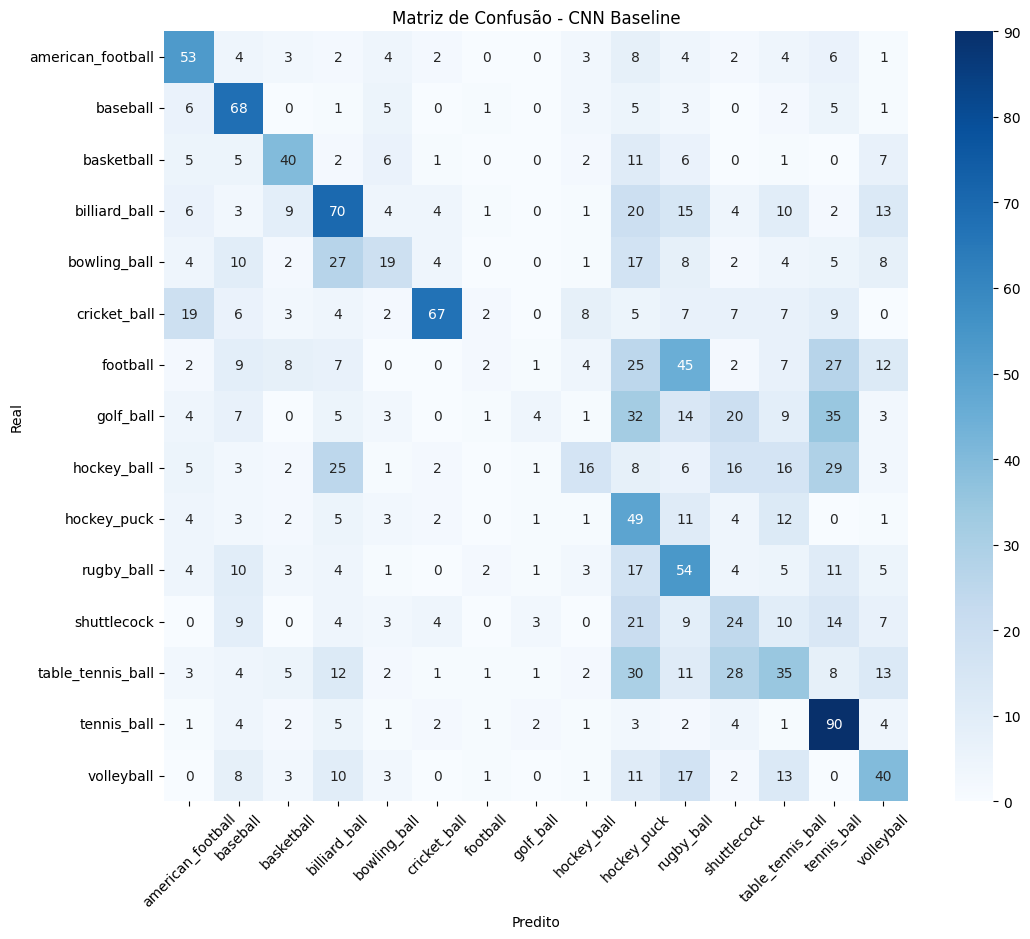

In [19]:
# Coletando predições e labels reais
y_true = []
y_pred = []

print('Coletando predições...')
for x_batch, y_batch in test_dataset:
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=-1))
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CNN Baseline')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Confere quais classes ele erra mais (Classification Report)
print('\n' + '='*60)
print('RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE')
print('='*60)
print(classification_report(y_true, y_pred, target_names=class_names))


RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE
                   precision    recall  f1-score   support

american_football       0.46      0.55      0.50        96
         baseball       0.44      0.68      0.54       100
       basketball       0.49      0.47      0.48        86
    billiard_ball       0.38      0.43      0.41       162
     bowling_ball       0.33      0.17      0.23       111
     cricket_ball       0.75      0.46      0.57       146
         football       0.17      0.01      0.02       151
        golf_ball       0.29      0.03      0.05       138
      hockey_ball       0.34      0.12      0.18       133
      hockey_puck       0.19      0.50      0.27        98
       rugby_ball       0.25      0.44      0.32       124
      shuttlecock       0.20      0.22      0.21       108
table_tennis_ball       0.26      0.22      0.24       156
      tennis_ball       0.37      0.73      0.49       123
       volleyball       0.34      0.37      0.35       109

         accura

# 4 Melhoria do Modelo Baseline (CNN Refinada)

Nesta seção, o objetivo é superar o baseline de 44.27%.

**Fluxo de Execução:**
1. O código verifica se o arquivo `best_refined_v2.keras` já existe no Google Drive.
2. **Se existir:** O modelo é carregado e o treinamento é pulado.
3. **Se não existir:** O pipeline de dados é configurado, a arquitetura é construída e o treinamento é iniciado.

### 4.1 Verificação de Modelo Existente

Primeiro, verificamos se o modelo já foi treinado e salvo no Google Drive para evitar re-treinamento.

In [21]:
import os
import tensorflow as tf

# Caminho do checkpoint no Drive
checkpoint_path_v2 = os.path.join(MODEL_DIR, 'best_refined_v2.keras')
MODELO_EXISTE = os.path.exists(checkpoint_path_v2)

if MODELO_EXISTE:
    print(f"Modelo encontrado em: {checkpoint_path_v2}")
    print("Carregando pesos...")
    refined_model = tf.keras.models.load_model(checkpoint_path_v2)
    print("Modelo pronto para uso.")
else:
    print("Modelo não encontrado. O pipeline de treinamento será preparado.")

Modelo não encontrado. O pipeline de treinamento será preparado.


In [22]:
if not MODELO_EXISTE:
    def load_image_refined_v2(path, label, augment=False):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0

        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.2)
            img = tf.image.random_contrast(img, 0.8, 1.2)
            zoom_factor = tf.random.uniform([], 0.9, 1.0)
            new_size = tf.cast(tf.cast(IMG_SIZE, tf.float32) * zoom_factor, tf.int32)
            img = tf.image.random_crop(img, size=[new_size[0], new_size[1], 3])
            img = tf.image.resize(img, IMG_SIZE)
        return img, label

    train_dataset_v2 = tf.data.Dataset.from_tensor_slices((train_paths_split, train_labels_split))
    train_dataset_v2 = train_dataset_v2.map(lambda x, y: load_image_refined_v2(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset_v2 = train_dataset_v2.shuffle(SHUFFLE_BUFFER, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    print("Pipeline de dados configurado.")
else:
    print("Pipeline ignorado (modelo carregado).")

Pipeline de dados configurado.


### 4.2 Arquitetura CNN Refinada

In [23]:
if not MODELO_EXISTE:
    def build_refined_model_v2(input_shape=(224, 224, 3), num_classes=15):
        model = tf.keras.models.Sequential(name='CNN_Refined_v2')
        model.add(tf.keras.layers.Input(shape=input_shape))
        # Bloco 1
        model.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same'))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        model.add(tf.keras.layers.MaxPooling2D((2, 2)))
        # Bloco 4 (Final)
        model.add(tf.keras.layers.Conv2D(256, (3, 3), padding='same'))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        model.add(tf.keras.layers.GlobalAveragePooling2D())
        model.add(tf.keras.layers.Dense(512, activation='relu'))
        model.add(tf.keras.layers.Dropout(0.5))
        model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
        return model

    refined_model = build_refined_model_v2()
    refined_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print("Arquitetura definida.")
else:
    print("Arquitetura ignorada (modelo carregado).")

Arquitetura definida.


### 4.3 Treinamento do Modelo v2

Utilizamos `ReduceLROnPlateau` mais agressivo e mais épocas para permitir que a rede mais profunda aprenda as representações necessárias.

In [24]:
if not MODELO_EXISTE:
    callbacks_v2 = [
        callbacks.ModelCheckpoint(checkpoint_path_v2, save_best_only=True, monitor='val_loss'),
        callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
    ]

    print('Iniciando Treinamento da CNN Refinada v2...')
    history_v2 = refined_model.fit(
        train_dataset_v2,
        validation_data=val_dataset,
        epochs=50,
        callbacks=callbacks_v2,
        class_weight=class_weights,
        verbose=1
    )
else:
    print("Treinamento pulado (modelo carregado do Drive).")

Iniciando Treinamento da CNN Refinada v2...
Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 54s 122ms/step - accuracy: 0.1712 - loss: 2.5484 - val_accuracy: 0.1120 - val_loss: 2.6237 - learning_rate: 5.0000e-04
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.2207 - loss: 2.4133 - val_accuracy: 0.2295 - val_loss: 2.4147 - learning_rate: 5.0000e-04
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 36s 107ms/step - accuracy: 0.2430 - loss: 2.3559 - val_accuracy: 0.2582 - val_loss: 2.2727 - learning_rate: 5.0000e-04
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.2538 - loss: 2.3121 - val_accuracy: 0.2172 - val_loss: 2.5147 - learning_rate: 5.0000e-04
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.2633 - loss: 2.2814 - val_accuracy: 0.2432 - val_loss: 2.2898 - learning_rate: 5.0000e-04
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 35s 101ms/step - accuracy: 0.2752 - loss: 2.2560 - val_accuracy: 0.2814 - val_loss: 2.2566 - learning_rate: 5.0000e-04
Epo

### 4.4 Avaliação de Desempenho do Modelo v2

In [25]:
test_loss_v2, test_acc_v2 = refined_model.evaluate(test_dataset)
print(f'\nTest Accuracy : {test_acc_v2:.4f}')
print(f'Melhoria em relação ao baseline: {(test_acc_v2 - test_acc)*100:+.2f}%')

58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.3857 - loss: 1.9768

Test Accuracy : 0.3857
Melhoria em relação ao baseline: +4.29%
